Connected to Python 3.9.6

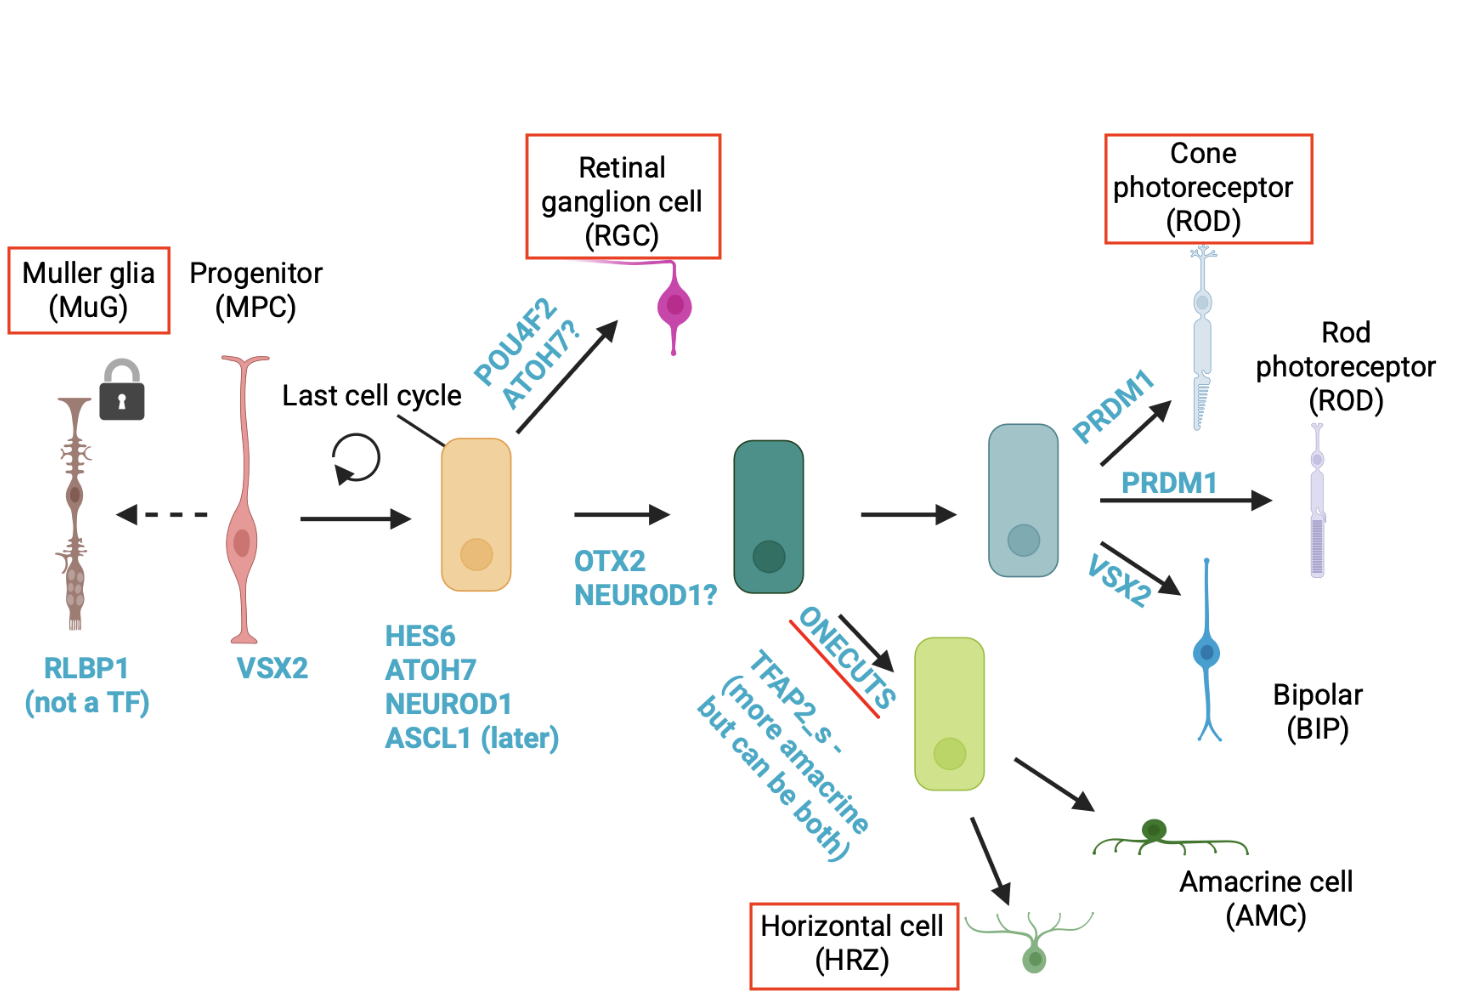

## RNA-seq

In [1]:
import scanpy as sc
retina_rna = sc.read_h5ad("/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Retina data/Rentina_RNA_main.h5ad")

In [10]:
retina_rna

AnnData object with n_obs × n_vars = 5412 × 23519
    obs: 'orig.ident', 'nCount.RNA', 'nFeature.RNA', 'barcode', 'gex.barcode', 'atac.barcode', 'is.cell', 'excluded.reason', 'gex.raw.reads', 'gex.mapped.reads', 'gex.conf.intergenic.reads', 'gex.conf.exonic.reads', 'gex.conf.intronic.reads', 'gex.conf.exonic.unique.reads', 'gex.conf.exonic.antisense.reads', 'gex.conf.exonic.dup.reads', 'gex.exonic.umis', 'gex.conf.intronic.unique.reads', 'gex.conf.intronic.antisense.reads', 'gex.conf.intronic.dup.reads', 'gex.intronic.umis', 'gex.conf.txomic.unique.reads', 'gex.umis.count', 'gex.genes.count', 'atac.raw.reads', 'atac.unmapped.reads', 'atac.lowmapq', 'atac.dup.reads', 'atac.chimeric.reads', 'atac.mitochondrial.reads', 'atac.fragments', 'atac.TSS.fragments', 'atac.peak.region.fragments', 'atac.peak.region.cutsites', 'nCount.ATAC', 'nFeature.ATAC', 'nucleosome.signal', 'nucleosome.percentile', 'TSS.enrichment', 'TSS.percentile', 'RNA.snn.res.0.8', 'seurat.clusters', 'S.Score', 'G2M.Score',

### Show cell type in UMAP plot

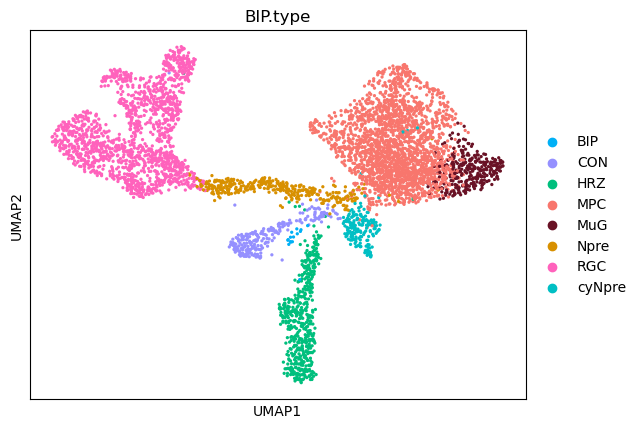

In [2]:
sc.pl.umap(retina_rna, color = 'BIP.type')

### Show pseudotime

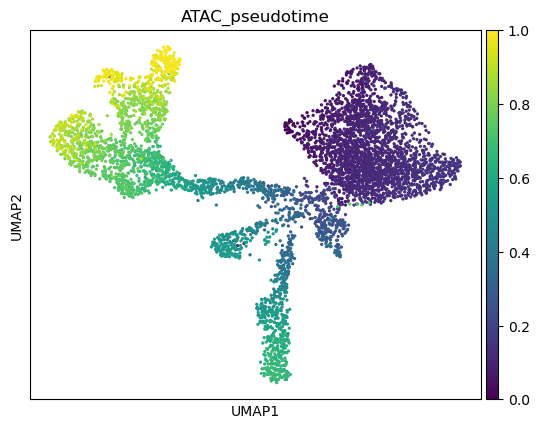

In [3]:
#connor suggested us to use ATAC pseudotime instead of RNA pseudotime
sc.pl.umap(retina_rna, color = 'ATAC_pseudotime') 

### remove MuG and BIP cells

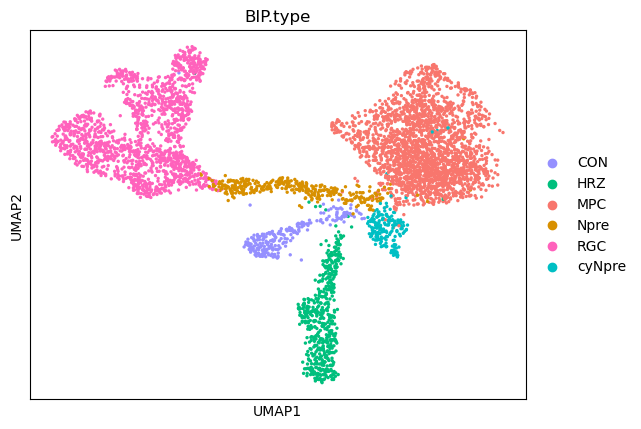

In [4]:
retina_subet = retina_rna[~retina_rna.obs['BIP.type'].isin(['MuG', 'BIP']),:]
sc.pl.umap(retina_subet, color = 'BIP.type')

## ATAC-seq

In [1]:
import scanpy as sc
retina_atac = sc.read_h5ad("/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Retina data/D59_multiome_ATAC_db_remv_tile.h5")

In [2]:
retina_atac

AnnData object with n_obs × n_vars = 5412 × 134694
    obs: 'orig.ident', 'nCount.RNA', 'nFeature.RNA', 'barcode', 'gex.barcode', 'atac.barcode', 'is.cell', 'excluded.reason', 'gex.raw.reads', 'gex.mapped.reads', 'gex.conf.intergenic.reads', 'gex.conf.exonic.reads', 'gex.conf.intronic.reads', 'gex.conf.exonic.unique.reads', 'gex.conf.exonic.antisense.reads', 'gex.conf.exonic.dup.reads', 'gex.exonic.umis', 'gex.conf.intronic.unique.reads', 'gex.conf.intronic.antisense.reads', 'gex.conf.intronic.dup.reads', 'gex.intronic.umis', 'gex.conf.txomic.unique.reads', 'gex.umis.count', 'gex.genes.count', 'atac.raw.reads', 'atac.unmapped.reads', 'atac.lowmapq', 'atac.dup.reads', 'atac.chimeric.reads', 'atac.mitochondrial.reads', 'atac.fragments', 'atac.TSS.fragments', 'atac.peak.region.fragments', 'atac.peak.region.cutsites', 'nCount.ATAC', 'nFeature.ATAC', 'nucleosome.signal', 'nucleosome.percentile', 'TSS.enrichment', 'TSS.percentile', 'RNA.snn.res.0.8', 'seurat.clusters', 'S.Score', 'G2M.Score'

In [ ]:
import pandas as pd
umap_coords = retina_atac.obsm['X_umap']
# Extract cell type labels
cell_types = retina_atac.obs['BIP.type']
df = pd.DataFrame({
    'umap1': umap_coords[:, 0],
    'umap2': umap_coords[:, 1],
    'BIP.type': cell_types.values
})
df.to_csv('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure5 Epigenetic Priming/UMAP retina/umap_data_retina_atac.csv', index=False)


### Show cell type in UMAP plot

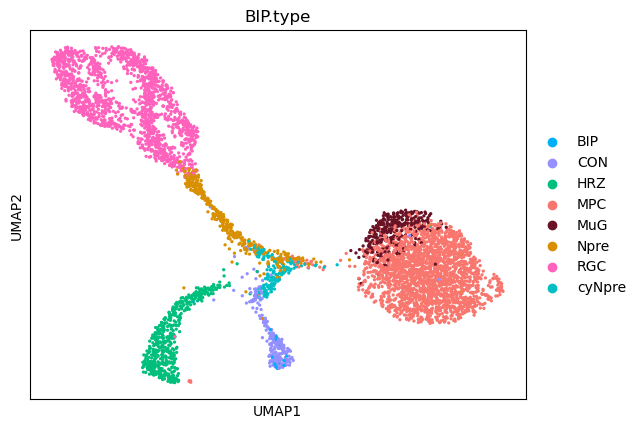

In [7]:
sc.pl.umap(retina_atac, color = 'BIP.type')

### Show pseudotime

Connected to base (Python 3.12.7)